In [2]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate

import random

# Brute–force Random optimisation

In [3]:
# problem = DTLZ1(n_dim = 10, n_obj = 2)
problem = ZDT1(n_dim = 10)
linear_model = LinearModel(problem = problem, random_state = 42)
choquet_model = ChoquetModel(problem = problem, random_state = 42)

rng = np.random.default_rng(0)
X   = rng.random((1000, problem.n_dim))                  # the unit cube [0, 1]^n_dim
for x in X:
    linear_model.F(x, linear_model.w)
    choquet_model.F(x, choquet_model.w)

linear_obj = linear_model.obj_hist
choquet_obj = choquet_model.obj_hist

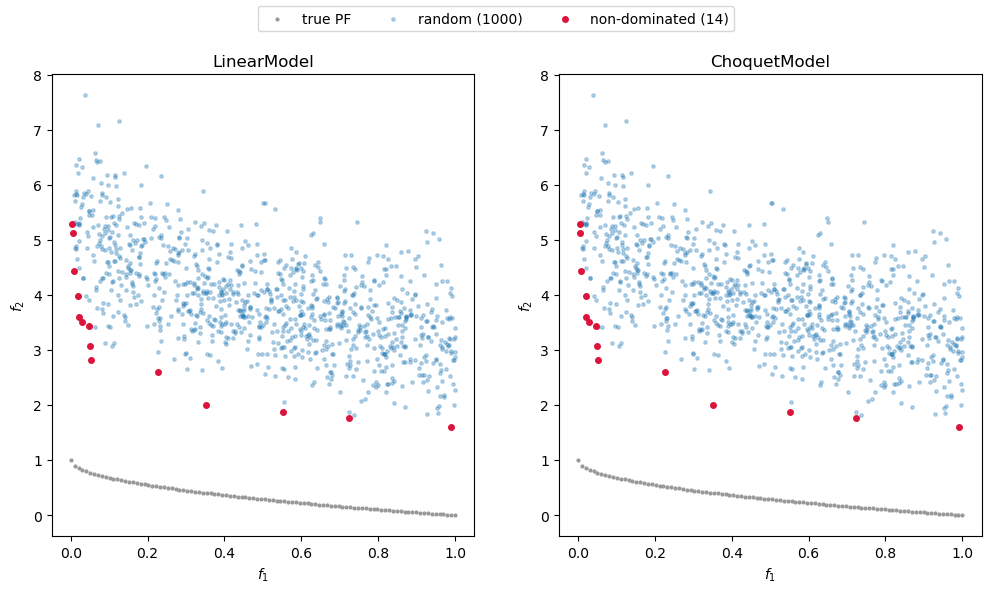

In [29]:
# ---- the random cloud, its non-dominated subset, and the analytical front ----
fig, axes = plt.subplots(1, 2, figsize = (12, 6))

for ax, model, obj in zip(axes.ravel(), [LinearModel, ChoquetModel], [linear_obj, choquet_obj]):
    keep = model.non_dominated(obj)
    pf, dim = problem.pareto_front(), problem.n_obj

    ax.scatter(*pf.T[:dim], s = 4, c = "0.6", label = "true PF")
    ax.scatter(*obj.T[:dim], s = 6, alpha = 0.3, label = f"random ({len(obj)})")
    ax.scatter(*obj[keep].T[:dim], s = 16, c = "crimson", label = f"non-dominated ({keep.sum()})")
    ax.set(xlabel = "$f_1$", ylabel = "$f_2$")
    ax.set_title(f"{model.__name__}")


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol = 3,
    fontsize = 10
)
# plt.tight_layout()
plt.show()

# Pareto Set is in the box constraints

In [5]:
# ZDT calling
linear_model = LinearModel(problem = ZDT2(n_dim = 2), max_iter = 50, random_state = 42)
choquet_model = ChoquetModel(problem = ZDT2(n_dim = 2), max_iter = 50, random_state = 42, method = 0)

# DTLZ calling
# linear_model = LinearModel(problem = DTLZ2(n_dim = 10, n_obj = 2), max_iter = 20, random_state = 42)
# choquet_model = ChoquetModel(problem = DTLZ2(n_dim = 10, n_obj = 2), max_iter = 20, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape} PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape}  PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (94, 2) PS (94, 2)
ChoquetModel:  PF (494, 2)  PS (494, 2)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,9.080785,441,94,50,0.063437
ChoquetModel,9.101014,1089,494,50,22.807749


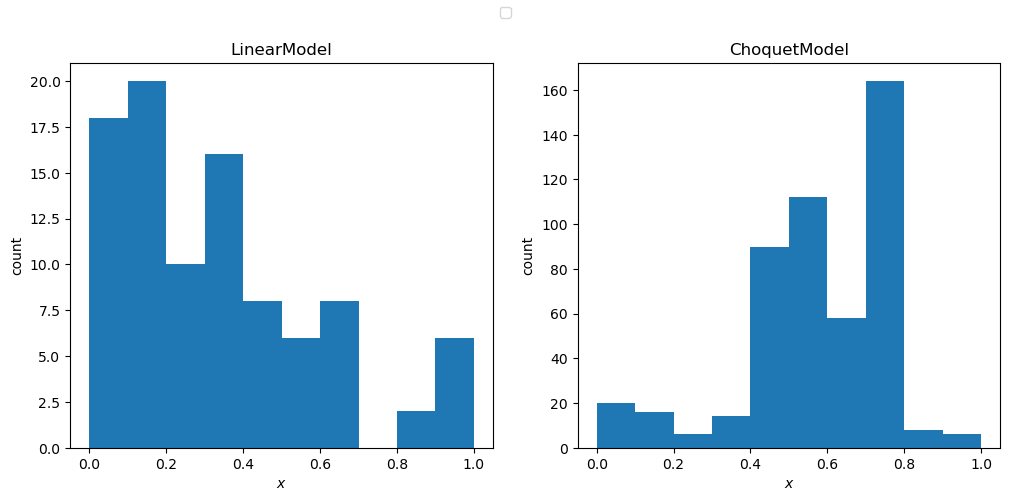

In [23]:
# ---- the random cloud, its non-dominated subset, and the analytical front ----
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

for ax, model, name in zip(axes, [linear_model, choquet_model], ["LinearModel", "ChoquetModel"]):
    true_ps = model.problem.pareto_set()            # the problem this model was solved on
    ax.hist(model.PS[:, 0])
    ax.set(xlabel = "$x$", ylabel = "count", title = name)



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol = 3,
    fontsize = 10
)
plt.show()

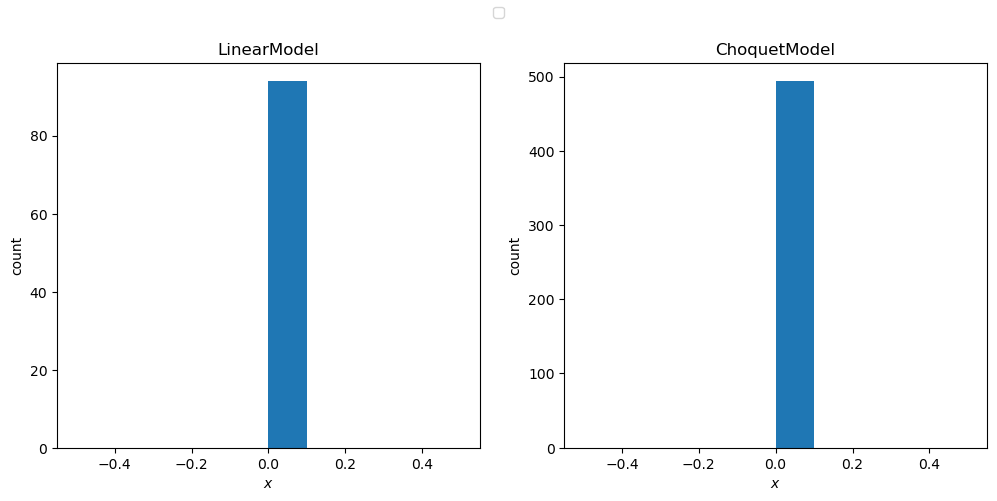

In [24]:
# ---- the random cloud, its non-dominated subset, and the analytical front ----
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

for ax, model, name in zip(axes, [linear_model, choquet_model], ["LinearModel", "ChoquetModel"]):
    true_ps = model.problem.pareto_set()            # the problem this model was solved on
    ax.hist(model.PS[:, 1])
    ax.set(xlabel = "$x$", ylabel = "count", title = name)



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol = 3,
    fontsize = 10
)
plt.show()